<a href="https://colab.research.google.com/github/sbauer01/remote-sensing-lc-sb/blob/main/remote_sensing/Random_forest_classifier_on_remote_sensing_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random forest classifier for landcover classification from remote sensing images

In this tasks, we will use a portion of the [SAT-6](https://csc.lsu.edu/~saikat/deepsat/) dataset from Louisiana State University and NASA Ames Research Center.

For this demonstration, we only use the test dataset, which consists of 81000 samples randomly distributed across 6 landcover classes.

In [1]:
# Random forest classifier for landcover classification
# Author: Ankit Patnala, JSC, 2025
# Download necessary packages if right kernel is not present
# Not needed in colab
#!pip install pandas
#!pip install scikit-learn
#!pip install matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

## Obtaining the data
The data is available via this B2share link [link](https://b2share.eudat.eu/records/89654eac10724d30a6c7e51f2c5422de). Download all the files at the same folder path where you are creating this notebook

Alternatively use the following wget commands to download the data

The following cell can be executed in Google colab

In [3]:
!wget https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/X_test_sat6.csv
!wget https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/y_test_sat6.csv
!wget https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/sat6annotations.csv

--2026-05-21 13:54:06--  https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/X_test_sat6.csv
Resolving b2share.eudat.eu (b2share.eudat.eu)... 86.50.166.117, 2001:708:10:6802::12
Connecting to b2share.eudat.eu (b2share.eudat.eu)|86.50.166.117|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/2p6ra-xfj86/files/X_test_sat6.csv [following]
--2026-05-21 13:54:08--  https://b2share.eudat.eu/records/2p6ra-xfj86/files/X_test_sat6.csv
Reusing existing connection to b2share.eudat.eu:443.
HTTP request sent, awaiting response... 200 OK
Length: 905628829 (864M) [text/plain]
Saving to: ‘X_test_sat6.csv.5’

X_test_sat6.csv.5   100%[===================>] 863.67M  8.72MB/s    in 96s     

2026-05-21 13:55:44 (9.01 MB/s) - ‘X_test_sat6.csv.5’ saved [905628829/905628829]

--2026-05-21 13:55:44--  https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/y_test_sat6.csv
Resolving b2share.eudat.eu (b2share.eudat.eu)... 86.5

In [4]:
# load the csv file with the image data. Each row belongs to one sample. Each sample has 3136 columns i.e. 4 channels (R,G,B, and NIR) and 28 \times 28 spatial size
landcover_df = pd.read_csv("./X_test_sat6.csv",header=None)
landcover_df

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
0,95,91,61,157,105,113,101,179,50,35,...,107,181,118,137,127,205,90,105,86,183
1,102,102,103,137,108,110,116,154,88,83,...,91,157,95,92,84,143,89,85,76,130
2,47,54,95,10,79,89,108,15,96,131,...,118,17,82,98,125,18,61,69,113,13
3,200,181,178,218,192,177,176,214,162,141,...,139,203,157,138,125,193,147,128,107,187
4,85,101,100,15,87,102,97,16,54,71,...,74,8,37,49,76,6,27,43,69,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80995,82,82,115,17,104,123,131,23,100,119,...,146,32,137,152,159,44,159,166,166,61
80996,170,148,147,174,203,188,163,190,211,197,...,134,172,163,154,136,175,172,157,143,177
80997,140,136,126,190,156,163,152,208,152,170,...,126,162,93,111,119,170,68,66,61,123
80998,89,87,99,13,64,66,89,9,16,26,...,111,15,49,52,97,11,47,56,102,9


&#x1F479;  _Task:_ Make sure you understand this data structure.

&#x1F479;  _Question:_ What would you need to do to extract only the green and the infrared channel from this data?

In [5]:
# Read the annotation file to get the annotation i.e. classname corresponding to the labels
annotations = pd.read_csv("./sat6annotations.csv", header=None)
print(annotations)
labels = annotations[0].values
print(f'class labels: {labels}')

             0  1  2  3  4  5  6
0     building  1  0  0  0  0  0
1  barren_land  0  1  0  0  0  0
2        trees  0  0  1  0  0  0
3    grassland  0  0  0  1  0  0
4         road  0  0  0  0  1  0
5        water  0  0  0  0  0  1
class labels: ['building' 'barren_land' 'trees' 'grassland' 'road' 'water']


The data structure that you see above is called _one-hot encoding_

&#x1F479; _Question:_ What is the advantage of this encoding compared to a simple class label like '0', '1', '2', '3', '4', '5', or text labels like 'building', 'barren_land', ...?

In [6]:
# load the csv file with the labels of all samples
labels_df = pd.read_csv("./y_test_sat6.csv",header=None)
print(labels_df)
# get the names of the class labels (here, only "0" to "5")
# These correspond to the labels printed above
column_names = labels_df.columns.values

       0  1  2  3  4  5
0      0  0  1  0  0  0
1      0  0  1  0  0  0
2      0  0  0  0  0  1
3      0  1  0  0  0  0
4      0  0  0  0  0  1
...   .. .. .. .. .. ..
80995  0  0  0  0  0  1
80996  0  1  0  0  0  0
80997  0  0  1  0  0  0
80998  0  0  0  0  0  1
80999  0  0  1  0  0  0

[81000 rows x 6 columns]


# Plot random samples for illustration

&#x1F479; _Task:_ Make sure you understand the following code for creating balanced samples from the overall dataset and the reshaping of ther data that is needed for plotting.

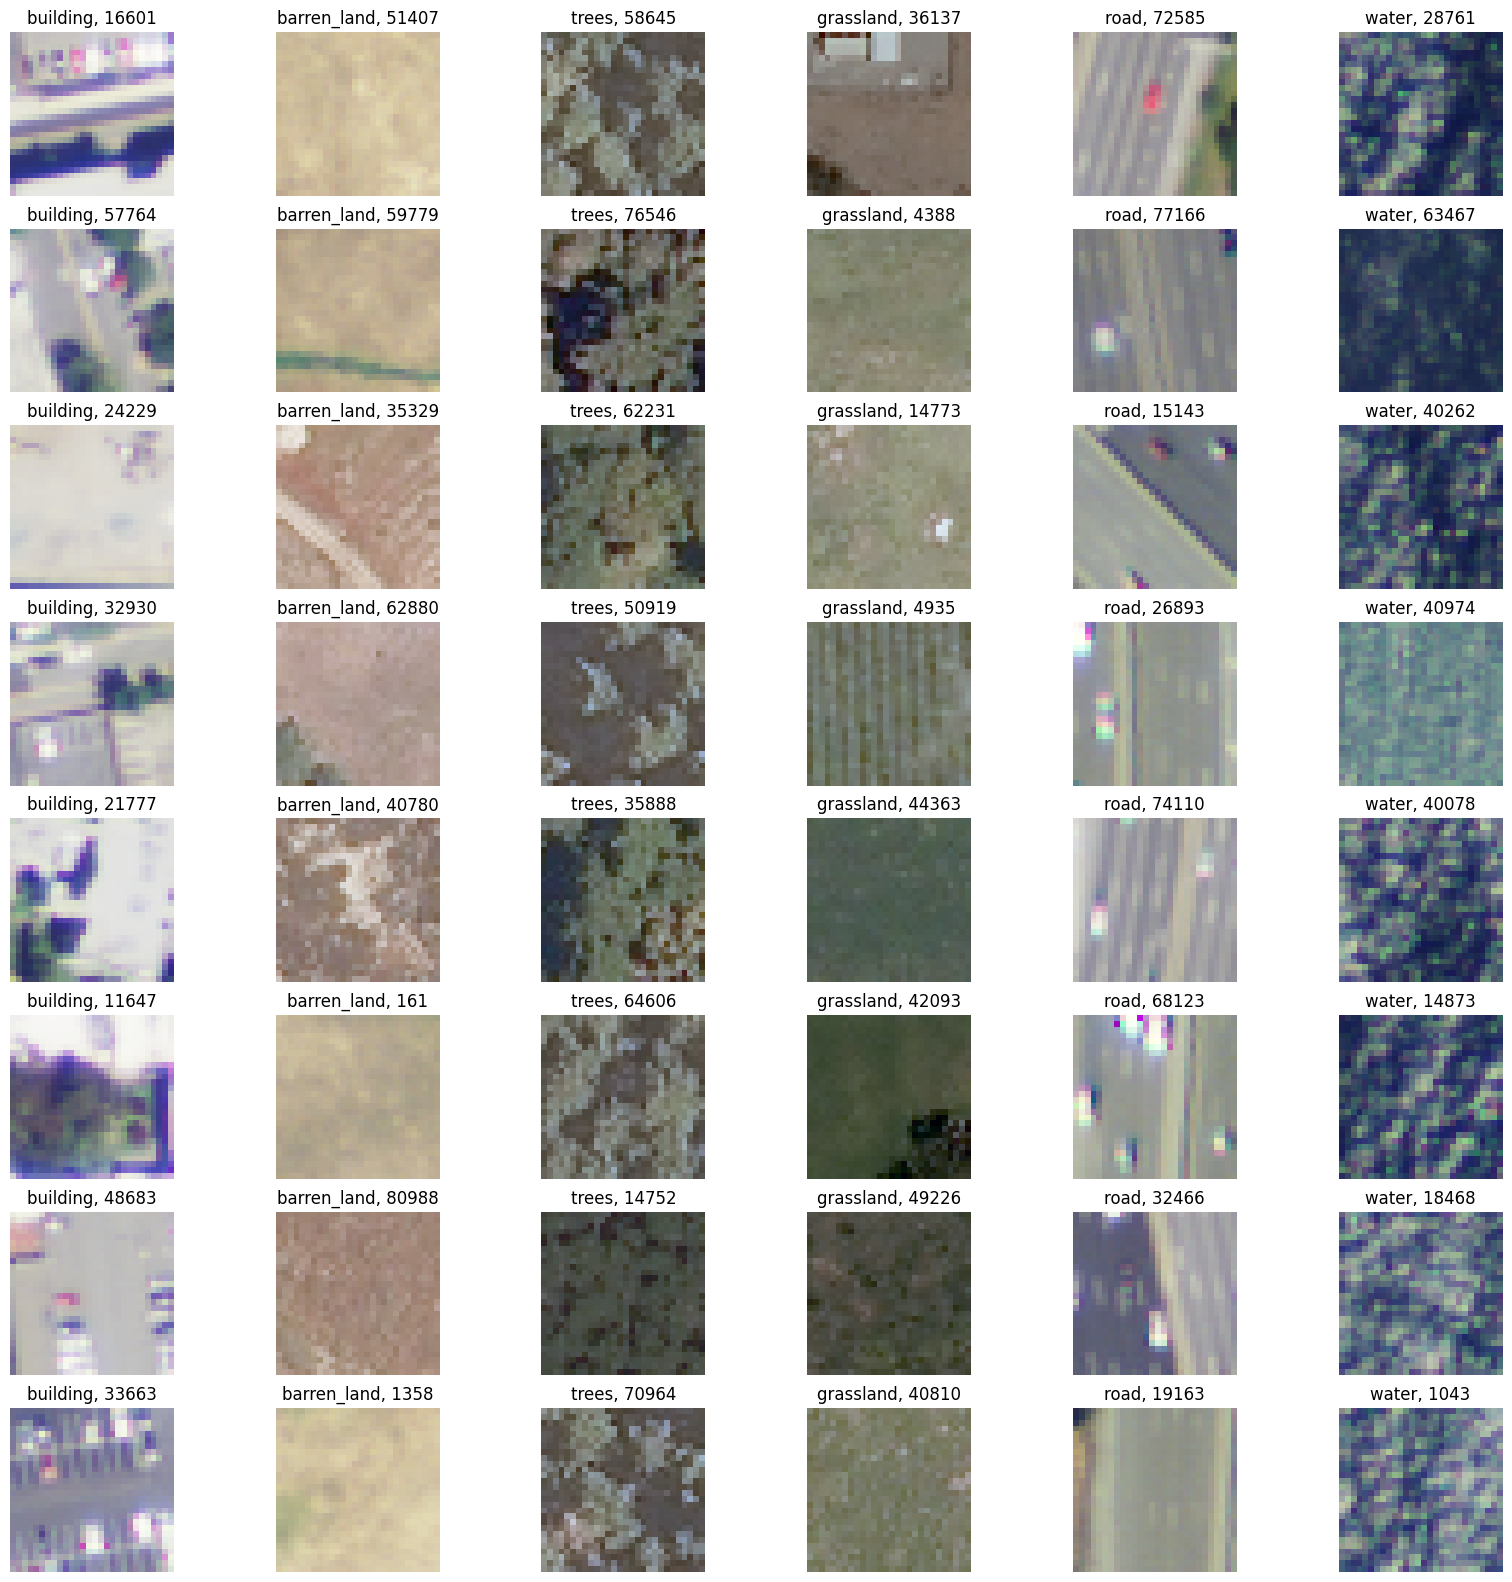

In [7]:
num_classes = len(column_names)
num_samples = 8  # number of rows to plot
sample_idx = []
for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_samples from this index list - make sure to avoid duplicates
    sample_idx.append(np.random.choice(np.where(class_idx.values)[0], size=num_samples, replace=False).tolist())

fig, ax = plt.subplots(num_samples, num_classes, figsize=(20,20))
for i in range(num_samples):
    for j in range(num_classes):
        data_index = sample_idx[j][i]
        ax[i,j].set_title(f"{labels[j]}, {data_index}")
        ax[i,j].axis('off')
        data = np.reshape(landcover_df.iloc[data_index].values,(-1,28,28,4))
        ax[i,j].imshow(data[0,...,:3])

### Create the training and test datasets

Collect equal number of samples from each class for training and testing, respectively

In [8]:
num_train = 1000
num_test = 100
train_idx = []
test_idx = []

np.random.seed(42) # Set a random seed for reproducibility

for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_train and num_test values from this index list - make sure to avoid duplicates
    train_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_train, replace=False).tolist())
    test_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_test, replace=False).tolist())
print(f'number of train indices: {len(train_idx)}, number of test indices: {len(test_idx)}')


number of train indices: 6000, number of test indices: 600


&#x1F479;  _Question:_ Why use `extend`here and `append` above?

&#x1F479;  _Question:_ What is wrong with the above code?

In [9]:
# Shuffle train and test indices
train_idx = np.random.permutation(train_idx)
test_idx = np.random.permutation(test_idx)
# Extract images and labels corresponding to the selected indices
train_X = landcover_df.iloc[train_idx]
train_y = labels_df.iloc[train_idx]
test_X = landcover_df.iloc[test_idx]
test_y = labels_df.iloc[test_idx]

&#x1F479; _Question:_ Why do you want to shuffle the samples in the train and test datasets?

In [10]:
train_X

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
13030,124,126,110,170,120,121,104,163,112,113,...,123,179,140,131,122,177,149,141,136,182
50081,157,139,133,159,159,139,132,157,156,138,...,148,159,168,154,149,165,160,146,137,157
50573,128,128,143,34,127,127,140,34,123,124,...,107,20,92,90,109,20,90,92,105,20
40848,149,137,129,182,165,156,153,192,145,143,...,137,180,134,133,122,169,125,119,101,161
37419,122,132,127,175,103,106,95,150,58,51,...,46,91,85,51,47,79,131,116,108,133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64358,155,159,166,56,136,133,159,43,133,129,...,199,104,208,207,202,109,211,210,204,114
18144,133,132,109,198,130,126,106,193,157,152,...,101,160,125,127,120,177,112,108,98,162
45471,90,90,74,146,94,94,86,146,85,86,...,66,153,85,88,72,158,86,87,66,155
73867,182,177,172,81,187,188,178,86,183,178,...,228,145,227,228,227,145,225,226,227,141


## Define and intialize random classifier from scikit-learn

In [11]:
rf = RandomForestClassifier(n_estimators=100)

## Train the random forest

In [12]:
rf.fit( train_X, train_y)

RandomForestClassifier()

## Check the prediction on the test set

In [13]:
rf.score(test_X, test_y)

0.9266666666666666

&#x1F479;  _Task:_ Add code to plot a couple of successes and failures (i.e., where predicted labels agree/disagree with the given labels in test_y)

## Check the prediction of every classification


In [14]:
print(labels)

['building' 'barren_land' 'trees' 'grassland' 'road' 'water']


In [15]:
corrected_test_y_df = labels_df.iloc[test_idx]


for i, column in enumerate(column_names):
  class_mask = corrected_test_y_df[column] == 1

  class_X = test_X.loc[class_mask]
  class_y = corrected_test_y_df.loc[class_mask]

  score = rf.score(class_X, class_y)

  print(f'Class: {labels[i]}, Accuracy: {score}')

Class: building, Accuracy: 0.9
Class: barren_land, Accuracy: 0.95
Class: trees, Accuracy: 0.97
Class: grassland, Accuracy: 0.83
Class: road, Accuracy: 0.91
Class: water, Accuracy: 1.0


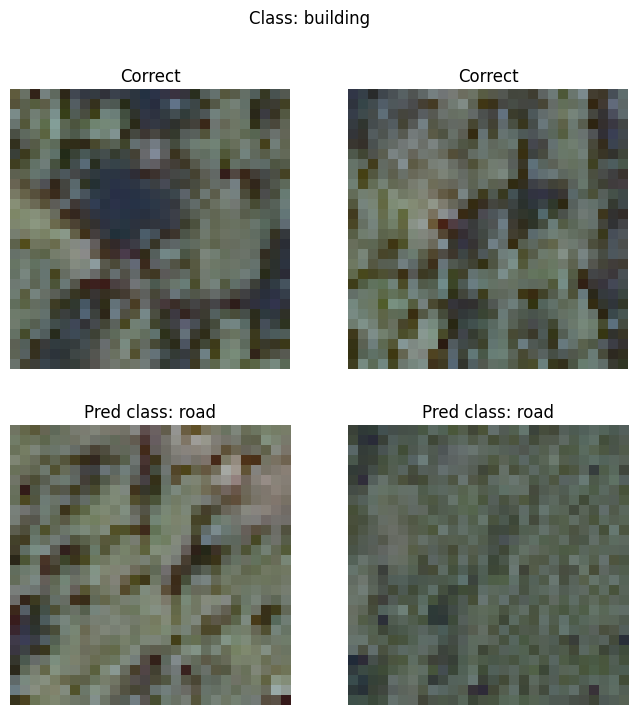

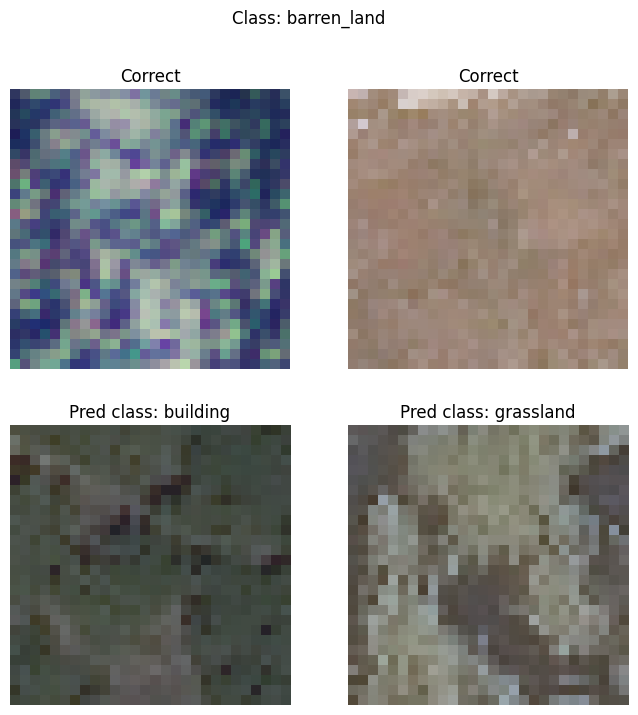

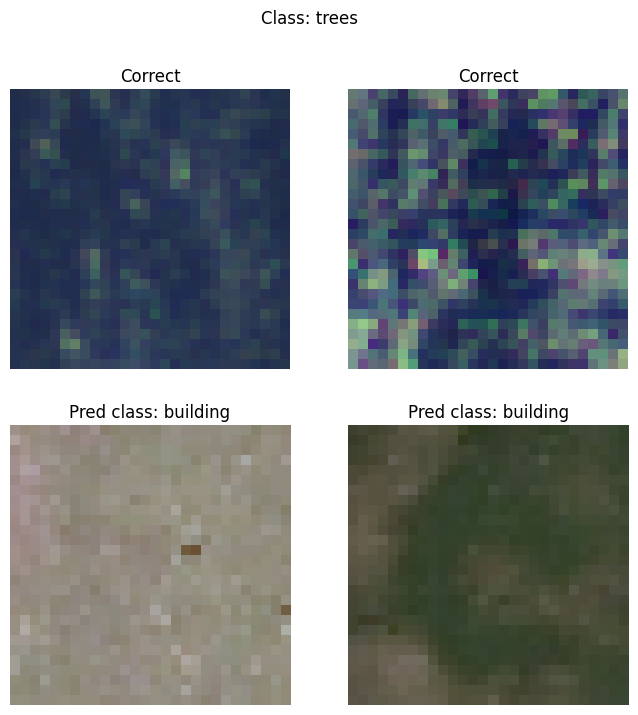

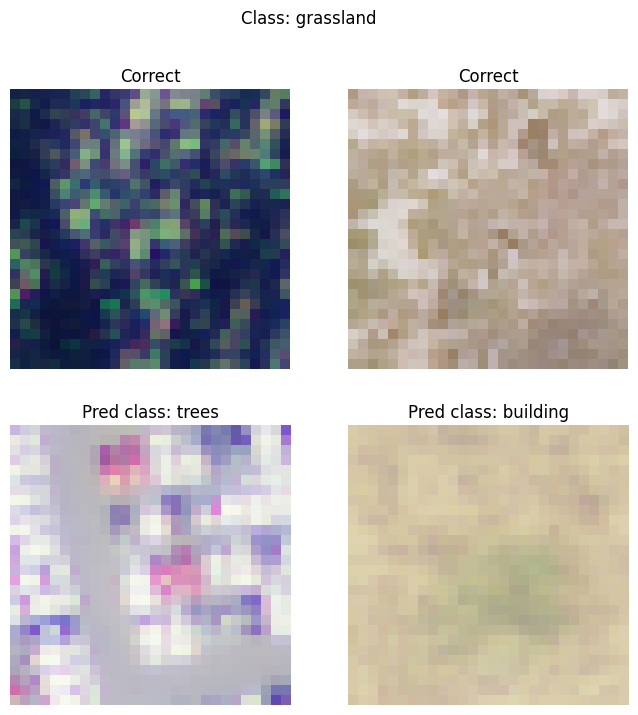

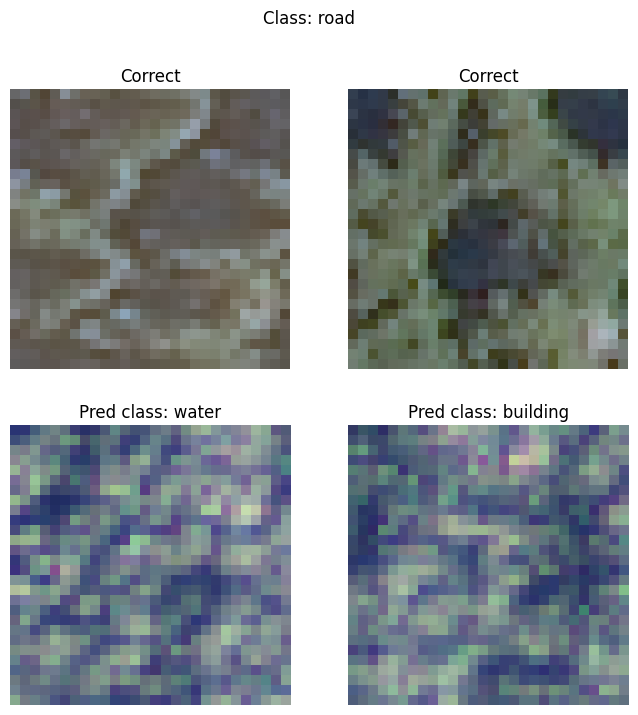

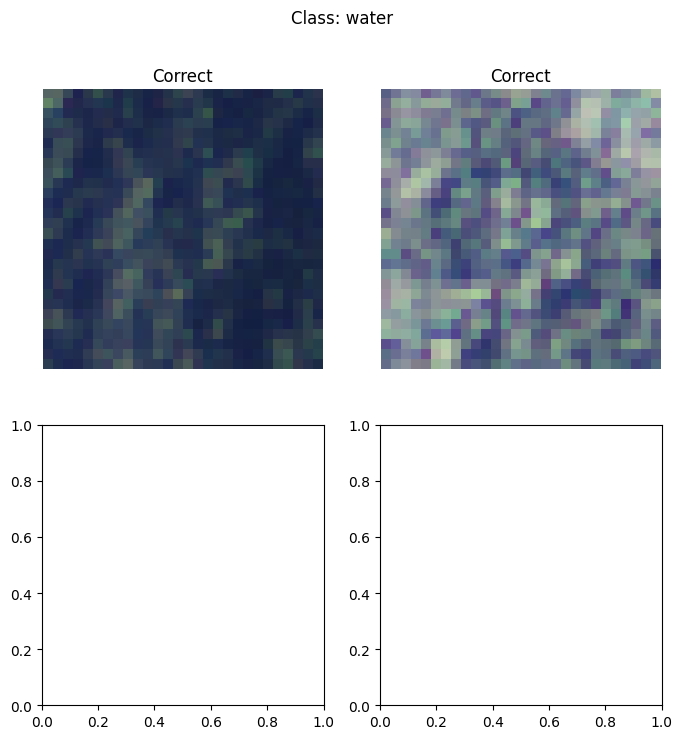

In [16]:
##Plot some examples for right and flase classifiscation

pred_y_int = np.argmax(rf.predict(test_X), axis=1)
true_y_int = np.argmax(corrected_test_y_df.values, axis=1)

for i, column in enumerate(column_names):
    class_mask = corrected_test_y_df[column] == 1
    class_X = test_X.loc[class_mask]
    class_y = corrected_test_y_df.loc[class_mask]

    score = rf.score(class_X, class_y)

    correct_samples = []
    false_samples = []

    class_positions = np.where(class_mask.values)[0]

    for idx in class_positions:

        if pred_y_int[idx] == true_y_int[idx]:
            correct_samples.append(idx)
        else:
            false_samples.append(idx)

    #only first two samples
    correct_samples = correct_samples[:2]
    false_samples = false_samples[:2]

    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    fig.suptitle(f'Class: {labels[i]}')


    #right classifiaction
    for j, data_index in enumerate(correct_samples):
          data = np.reshape(landcover_df.iloc[data_index].values,(-1, 28, 28, 4))
          axes[0, j].imshow(data[0, ..., :3])
          axes[0, j].set_title("Correct")
          axes[0, j].axis("off")

    #misclassification
    for j, data_index in enumerate(false_samples):
      data = np.reshape(landcover_df.iloc[data_index].values,(-1, 28, 28, 4))
      pred_label = labels[pred_y_int[data_index]]
      true_label = labels[true_y_int[data_index]]
      axes[1, j].imshow(data[0, ..., :3])
      axes[1, j].set_title(f"Pred class: {pred_label}")
      axes[1, j].axis("off")

    plt.show()




Because the accuracy of the class water is 1.0, there is no false predicted sample

## Use of only the R, G and B color channels

In [17]:
channels=4
num_pixels = 28*28 # amount of pixels


rgb_column_indices = []
for i in range(num_pixels): # index i*4+3 is NIR channel
    # Red channel (index i*4)
    rgb_column_indices.append(i * channels)
    # Green channel (index i*4 + 1)
    rgb_column_indices.append(i * channels + 1)
    # Blue channel (index i*4 + 2)
    rgb_column_indices.append(i * channels + 2)

# new Dataframe with only RGB channels
landcover_rgb_df = landcover_df[rgb_column_indices]


print(landcover_rgb_df.shape)

(81000, 2352)


In [18]:
# Extract images and labels
train_X_rgb = landcover_rgb_df.iloc[train_idx]
train_y_rgb = labels_df.iloc[train_idx]
test_X_rgb = landcover_rgb_df.iloc[test_idx]
test_y_rgb = labels_df.iloc[test_idx]


rf_rgb = RandomForestClassifier(n_estimators=100)
rf_rgb.fit( train_X_rgb, train_y_rgb)
rf_rgb.score(test_X_rgb, test_y_rgb)

0.905

The score of the classification is worse than with the NIR channel

In [19]:
corrected_test_y_rgb_df = labels_df.iloc[test_idx]


for i, column in enumerate(column_names):
  class_mask = corrected_test_y_rgb_df[column] == 1

  class_X_rgb = test_X_rgb.loc[class_mask]
  class_y_rgb = corrected_test_y_rgb_df.loc[class_mask]

  score = rf_rgb.score(class_X_rgb, class_y_rgb)

  print(f'Class: {labels[i]}, Accuracy: {score}')

Class: building, Accuracy: 0.91
Class: barren_land, Accuracy: 0.94
Class: trees, Accuracy: 0.94
Class: grassland, Accuracy: 0.81
Class: road, Accuracy: 0.85
Class: water, Accuracy: 0.98


If we go into the details, so the score of each class, we see, that some classes, e.g. grassland performe worse (-12% of accuracy) than others, e.g  trees (-3% of accuracy). So for some classes, the NIR channel is more important than for others.

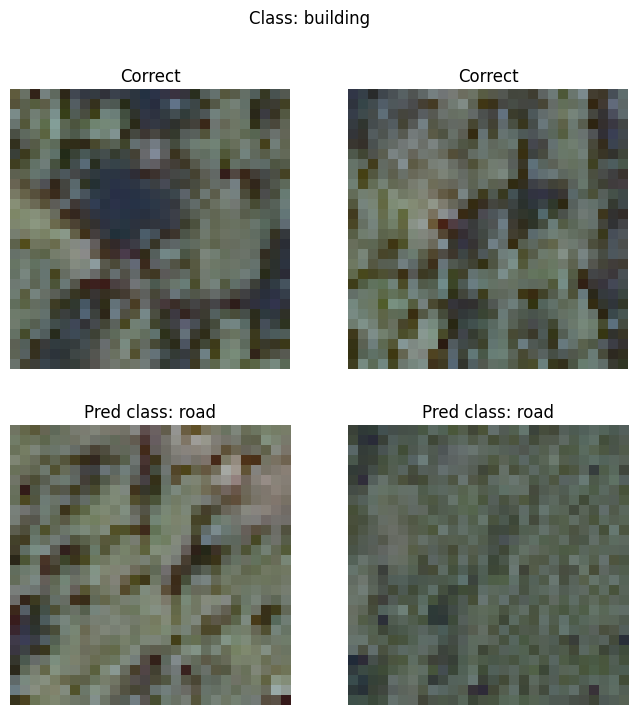

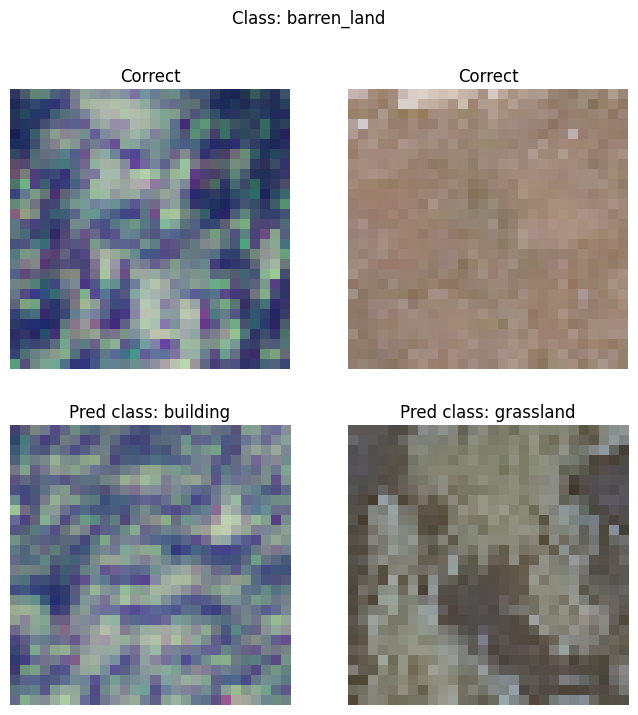

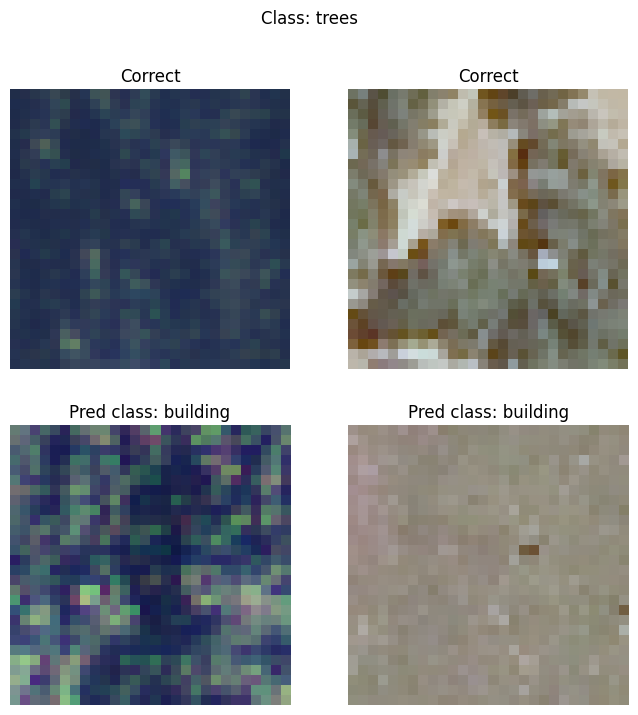

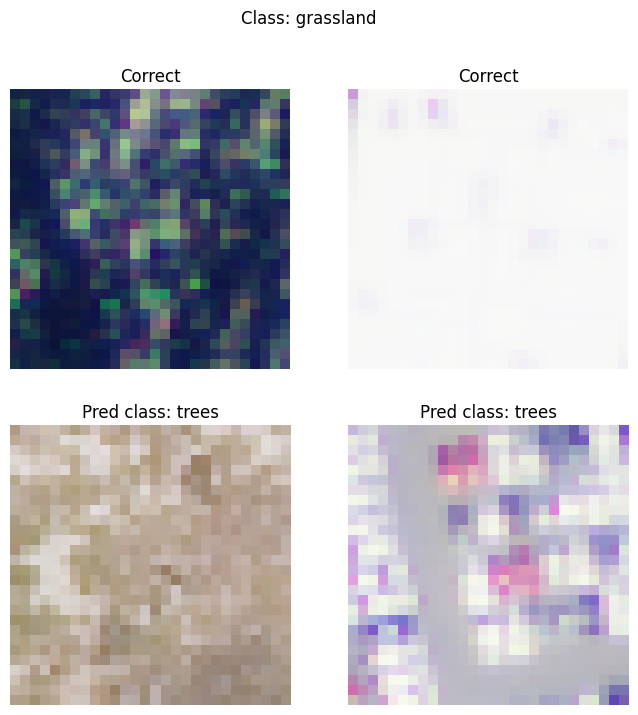

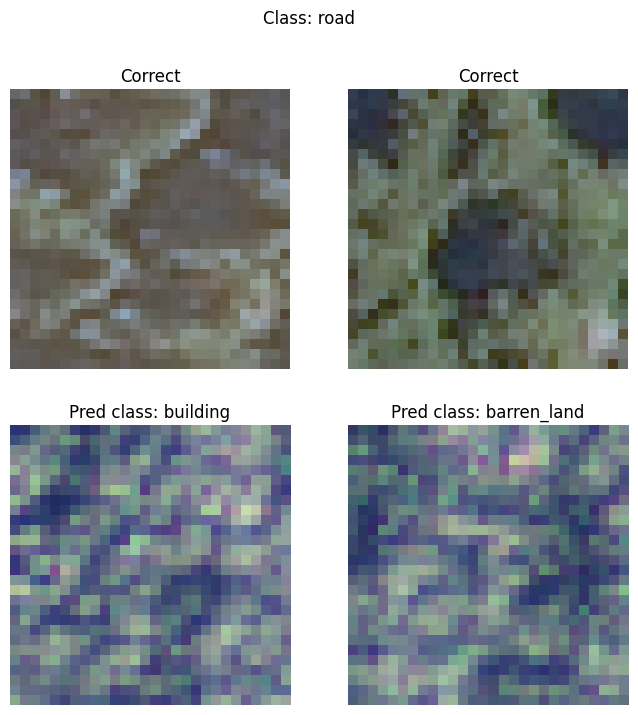

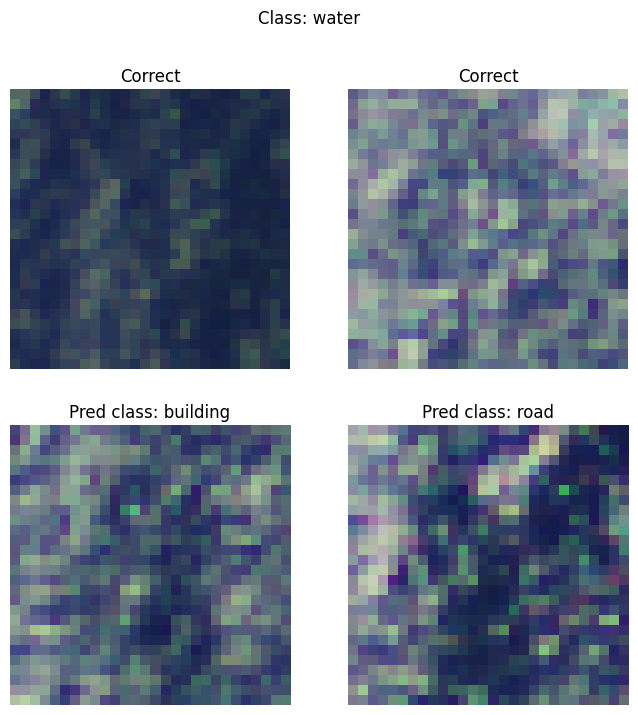

In [20]:
##Plot some examples for right and flase classifiscation

pred_y_int = np.argmax(rf_rgb.predict(test_X_rgb), axis=1)
true_y_int = np.argmax(corrected_test_y_rgb_df.values, axis=1)

for i, column in enumerate(column_names):
    class_mask = corrected_test_y_rgb_df[column] == 1
    class_X = test_X_rgb.loc[class_mask]
    class_y = corrected_test_y_rgb_df.loc[class_mask]

    score = rf_rgb.score(class_X, class_y)

    correct_samples = []
    false_samples = []

    class_positions = np.where(class_mask.values)[0]

    for idx in class_positions:

        if pred_y_int[idx] == true_y_int[idx]:
            correct_samples.append(idx)
        else:
            false_samples.append(idx)

    #only first two samples
    correct_samples = correct_samples[:2]
    false_samples = false_samples[:2]

    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    fig.suptitle(f'Class: {labels[i]}')


    #right classifiaction
    for j, data_index in enumerate(correct_samples):
          data = np.reshape(landcover_rgb_df.iloc[data_index].values,(-1, 28, 28, 3))
          axes[0, j].imshow(data[0, ..., :3])
          axes[0, j].set_title("Correct")
          axes[0, j].axis("off")

    #misclassification
    for j, data_index in enumerate(false_samples):
      data = np.reshape(landcover_rgb_df.iloc[data_index].values,(-1, 28, 28, 3))
      pred_label = labels[pred_y_int[data_index]]
      true_label = labels[true_y_int[data_index]]
      axes[1, j].imshow(data[0, ..., :3])
      axes[1, j].set_title(f"Pred class: {pred_label}")
      axes[1, j].axis("off")

    plt.show()

### Use of only R, G and NIR channel

In [21]:
rgnir_column_indices = []
for i in range(num_pixels): # index i*4+3 is NIR channel
    # Red channel
    rgnir_column_indices.append(i * channels)
    # Green channel
    rgnir_column_indices.append(i * channels + 1)
    # NIR channel
    rgnir_column_indices.append(i * channels + 3)

# new Dataframe with only RGB channels
landcover_rgnir_df = landcover_df[rgnir_column_indices]


# Extract images and labels
train_X_rgnir = landcover_rgnir_df.iloc[train_idx]
train_y_rgnir = labels_df.iloc[train_idx]
test_X_rgnir = landcover_rgnir_df.iloc[test_idx]
test_y_rgnir = labels_df.iloc[test_idx]


rf_rgnir = RandomForestClassifier(n_estimators=100)
rf_rgnir.fit( train_X_rgnir, train_y_rgnir)
rf_rgnir.score(test_X_rgnir, test_y_rgnir)

0.9266666666666666

The accuracy for the use of the R,G and NIR channels is slightly better (~ plus 1%) than the use of R,G and B. But it is still worse than the use of all four channels

In [22]:
corrected_test_y_rgnir_df = labels_df.iloc[test_idx]


for i, column in enumerate(column_names):
  class_mask = corrected_test_y_rgnir_df[column] == 1

  class_X_rgnir = test_X_rgnir.loc[class_mask]
  class_y_rgnir = corrected_test_y_rgnir_df.loc[class_mask]

  score = rf_rgnir.score(class_X_rgnir, class_y_rgnir)

  print(f'Class: {labels[i]}, Accuracy: {score}')

Class: building, Accuracy: 0.89
Class: barren_land, Accuracy: 0.95
Class: trees, Accuracy: 0.97
Class: grassland, Accuracy: 0.85
Class: road, Accuracy: 0.9
Class: water, Accuracy: 1.0


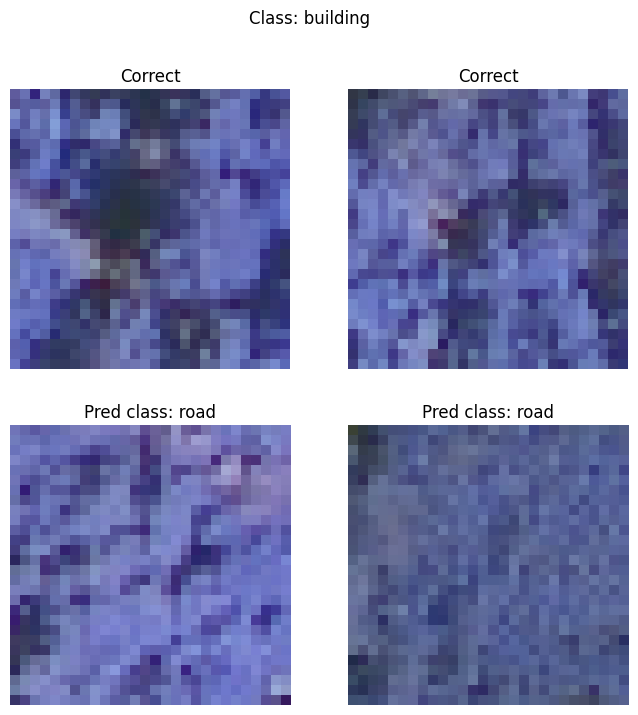

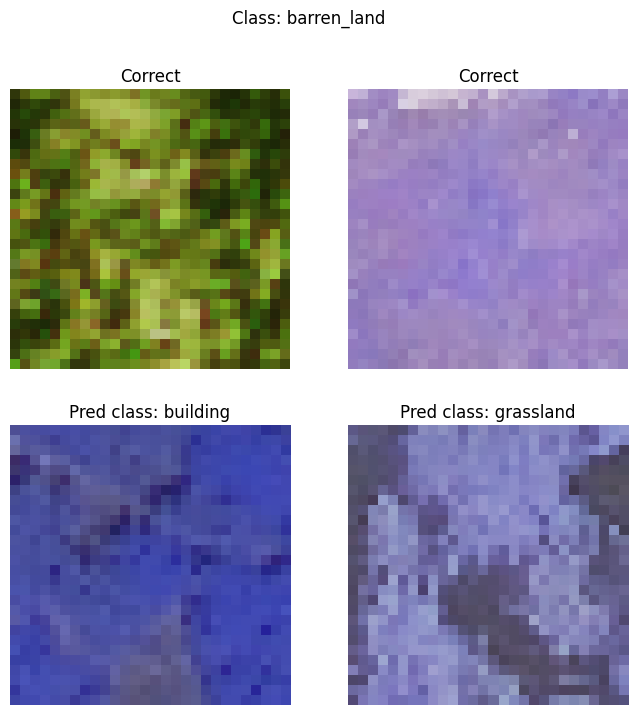

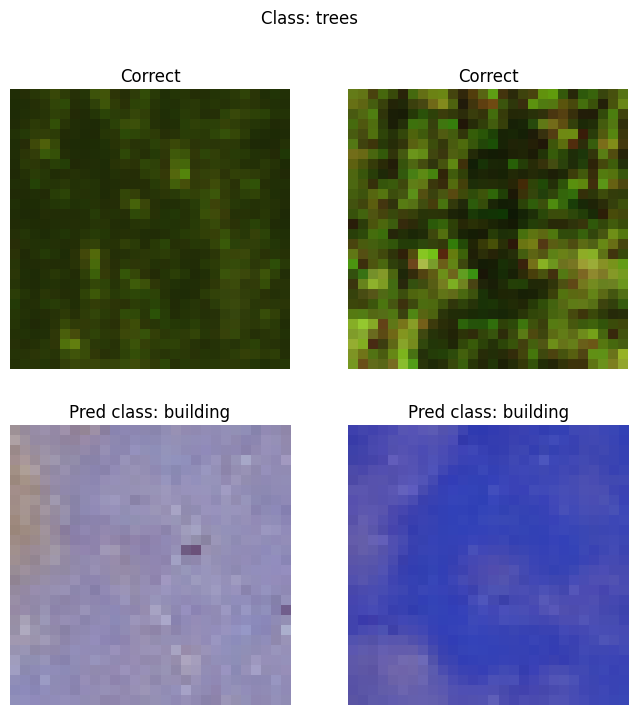

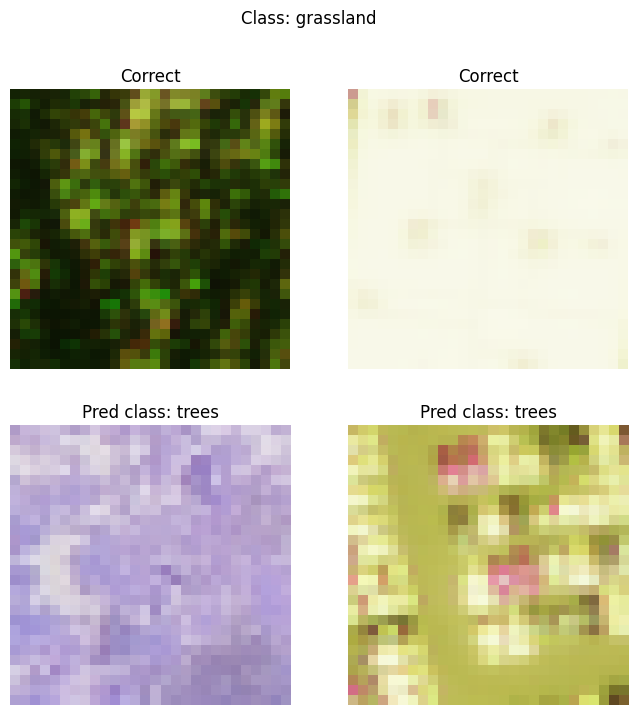

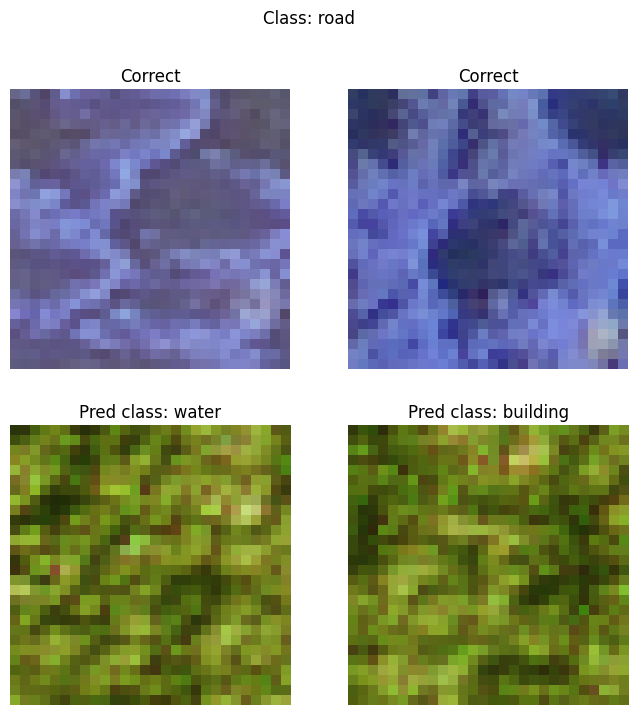

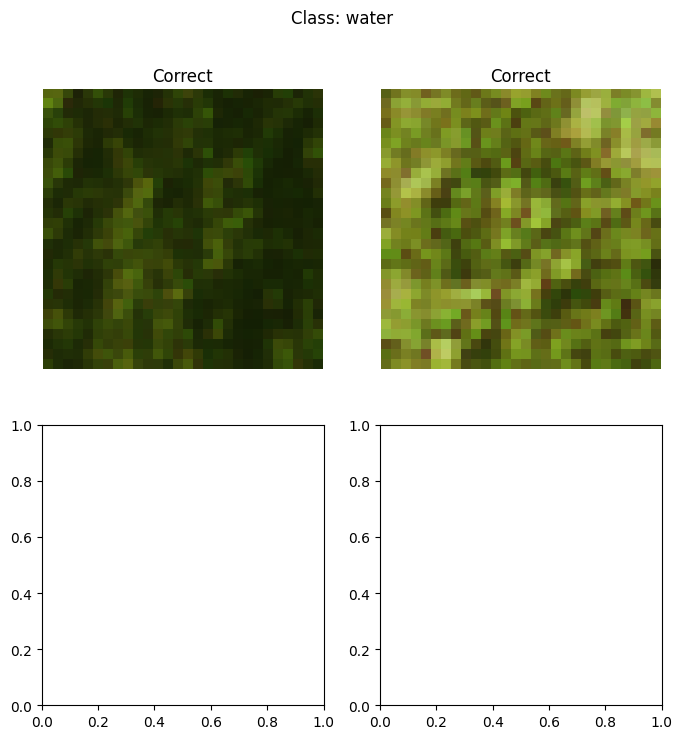

In [23]:
pred_y_int = np.argmax(rf_rgnir.predict(test_X_rgnir), axis=1)
true_y_int = np.argmax(corrected_test_y_rgnir_df.values, axis=1)

for i, column in enumerate(column_names):
    class_mask = corrected_test_y_rgnir_df[column] == 1
    class_X = test_X_rgnir.loc[class_mask]
    class_y = corrected_test_y_rgnir_df.loc[class_mask]

    score = rf_rgnir.score(class_X, class_y)

    correct_samples = []
    false_samples = []

    class_positions = np.where(class_mask.values)[0]

    for idx in class_positions:

        if pred_y_int[idx] == true_y_int[idx]:
            correct_samples.append(idx)
        else:
            false_samples.append(idx)

    #only first two samples
    correct_samples = correct_samples[:2]
    false_samples = false_samples[:2]

    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    fig.suptitle(f'Class: {labels[i]}')


    #right classifiaction
    for j, data_index in enumerate(correct_samples):
          data = np.reshape(landcover_rgnir_df.iloc[data_index].values,(-1, 28, 28, 3))
          axes[0, j].imshow(data[0, ..., :3])
          axes[0, j].set_title("Correct")
          axes[0, j].axis("off")

    #misclassification
    for j, data_index in enumerate(false_samples):
      data = np.reshape(landcover_rgnir_df.iloc[data_index].values,(-1, 28, 28, 3))
      pred_label = labels[pred_y_int[data_index]]
      true_label = labels[true_y_int[data_index]]
      axes[1, j].imshow(data[0, ..., :3])
      axes[1, j].set_title(f"Pred class: {pred_label}")
      axes[1, j].axis("off")

    plt.show()

## Change of Hyper parameters


In [56]:
num_train= 1000
num_test_new = 300 # triple the amount of training samples
train_idx = []
test_idx = []

np.random.seed(42) # Set a random seed for reproducibility

for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_train and num_test values from this index list - make sure to avoid duplicates
    train_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_train, replace=False).tolist())
    test_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_test_new, replace=False).tolist())
print(f'number of train indices: {len(train_idx)}, number of test indices: {len(test_idx)}')


number of train indices: 6000, number of test indices: 1800


In [57]:
# Shuffle train and test indices
train_idx = np.random.permutation(train_idx)
test_idx = np.random.permutation(test_idx)
# Extract images and labels corresponding to the selected indices
train_X = landcover_df.iloc[train_idx]
train_y = labels_df.iloc[train_idx]
test_X = landcover_df.iloc[test_idx]
test_y = labels_df.iloc[test_idx]

In [58]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit( train_X, train_y)
rf.score(test_X, test_y)


0.9333333333333333

In [55]:
corrected_test_y_df = labels_df.iloc[test_idx]


for i, column in enumerate(column_names):
  class_mask = corrected_test_y_df[column] == 1

  class_X = test_X.loc[class_mask]
  class_y = corrected_test_y_df.loc[class_mask]

  score = rf.score(class_X, class_y)

  print(f'Class: {labels[i]}, Accuracy: {score}')

Class: building, Accuracy: 0.95
Class: barren_land, Accuracy: 0.96
Class: trees, Accuracy: 0.98
Class: grassland, Accuracy: 0.86
Class: road, Accuracy: 0.98
Class: water, Accuracy: 1.0
